# Module 6 Project — Feature Engineering and XAI

**Author**: deffip2@illinois.edu

### Objective: Implementing FEature Engineeringa and XAI to predict tornado counts

This notebook:
1) Loads and preprocesses the data from climate indices (ENSO, PDO, NAO and AO) and tornado record in the US

2) Builds two Random Forest regression models:
   - **Model 1**: climate indices only  
   - **Model 2**: climate indices + one-hot encoded month

3) Applies feature engineering with `feature_engine` (median imputation, one-hot encoding).

4) Tunes both models with `Pipeline` + `GridSearchCV` and evaluates them using **RMSE**, **R²**, and **correlation**.

5) Uses XAI methods to interpret the models:
   - Feature importance and multipass permutation importance  
   - SHAP summary plots and SHAP dependence for ENSO

> **Data**: SPC tornado records (`1950–2021_actual_tornadoes.csv`) and Module 4 climate index file (`M04_climate_indices.csv`).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from copy import deepcopy

import shap

from feature_engine import imputation as mdi
from feature_engine import encoding as ce


## 1. DATA PREPROCESSING

In this section, we will prepare the data for Module 6. There are two types of data require for Module 6, including:
1. Tornado data base from SPC NOAA in csv format
2. Climate indices from Module 4 Notebook 1 including ENSO, PDO, NAO, and AO in csv format from multiple data sources.

### 1. SPC NOAA monthly tornado data

In this subsection, we will:
1. Load the data from SPC NOAA where the data is stored in daily time scale
2. We reprocess the data and produce monthly aggregate for a certain area (Illinois
3. We merge both dataset into one for further data processing

In [2]:
url_torn = "https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv"
torn = pd.read_csv(url_torn)

torn[['yr', 'mo', 'dy', 'st']].head(10) 

,yr,mo,dy,st
0,1950,10,1,OK
1,1950,10,9,NC
2,1950,11,20,KY
3,1950,11,20,KY
4,1950,11,20,MS
5,1950,11,4,PA
6,1950,12,2,IL
7,1950,12,2,IL
8,1950,12,2,AR
9,1950,12,2,IL


In [3]:
# Filter tornado for illinois only
torn_il = torn[torn['st'] == 'IL'].copy()

torn_il['date'] = pd.to_datetime(
    dict(year=torn_il['yr'], month=torn_il['mo'], day=torn_il['dy'])
)

torn_il['year'] = torn_il['date'].dt.year
torn_il['month'] = torn_il['date'].dt.month

# Aggregate to monthly data
tornado_monthly = (
    torn_il
    .groupby(['year', 'month'])
    .size()
    .reset_index(name='tornado_count_IL')
)

In [4]:
tornado_monthly['time'] = pd.to_datetime(
    dict(year=tornado_monthly['year'],
         month=tornado_monthly['month'],
         day=1)
)

tornado_monthly.head(10)

,year,month,tornado_count_IL,time
0,1950,1,2,1950-01-01
1,1950,3,1,1950-03-01
2,1950,6,1,1950-06-01
3,1950,7,1,1950-07-01
4,1950,12,3,1950-12-01
5,1951,6,2,1951-06-01
6,1951,11,2,1951-11-01
7,1951,12,1,1951-12-01
8,1952,3,2,1952-03-01
9,1952,5,1,1952-05-01


### 2. Climate indices data

We have stored the climate indices data from Module 4 Notebook 1 (M04N01) and load the data here :)


I run the codes below in M04N01


*newdf_all = newdf_all.reset_index() \
newdf_all.to_csv("/data/keeling/a/deffip2/ATMS_523/HW_6_Module_6/ATMS-523-Module-6-deffip2/M04_climate_indices.csv", index=False)*


In [5]:
clim = pd.read_csv("M04_climate_indices.csv")

clim.head(10)

,Date,ENSO,PDO,NAO,AO
0,1951-01-01,1.5,-1.19,0.08,-0.085
1,1951-02-01,0.9,-1.52,0.70,-0.400
2,1951-03-01,-0.1,-1.72,-1.02,-1.934
3,1951-04-01,-0.3,-1.35,-0.22,-0.776
4,1951-05-01,-0.7,-1.29,-0.59,-0.863
5,1951-06-01,0.2,-1.77,-1.64,-0.918
6,1951-07-01,-1.0,-0.23,1.37,0.090
7,1951-08-01,-0.2,-1.76,-0.22,-0.377
8,1951-09-01,-1.1,-0.78,-1.36,-0.818
9,1951-10-01,-1.0,-0.09,1.87,-0.213


In [6]:
clim['Date'] = pd.to_datetime(clim['Date'])
clim = clim.rename(columns={'Date': 'time'})

clim.tail(10)


,time,ENSO,PDO,NAO,AO
890,2025-03-01,1.7,-1.12,0.30,0.556
891,2025-04-01,0.5,-1.15,0.18,0.268
892,2025-05-01,0.4,-1.66,0.49,0.904
893,2025-06-01,0.3,-2.62,0.70,1.134
894,2025-07-01,0.6,-4.16,0.48,0.500
895,2025-08-01,0.4,-3.20,0.26,0.036
896,2025-09-01,0.0,-2.33,-0.80,0.048
897,2025-10-01,NaN,-2.40,-0.96,0.064
898,2025-11-01,NaN,NaN,NaN,NaN
899,2025-12-01,NaN,NaN,NaN,NaN


### 3. Merge tornado and climate indices

In [7]:
df = pd.merge(tornado_monthly, clim, on='time', how='inner')

df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

df.head(10)


,year,month,tornado_count_IL,time,ENSO,PDO,NAO,AO
0,1951,6,2,1951-06-01,0.2,-1.77,-1.64,-0.918
1,1951,11,2,1951-11-01,-0.8,-0.31,-0.39,-0.069
2,1951,12,1,1951-12-01,-0.7,-1.45,1.32,1.987
3,1952,3,2,1952-03-01,0.5,-1.67,-1.49,-1.859
4,1952,5,1,1952-05-01,0.8,-2.07,-1.12,-0.774
5,1952,7,1,1952-07-01,0.5,-2.05,-0.09,0.383
6,1953,3,1,1953-03-01,-0.2,-1.27,-0.04,1.068
7,1953,4,2,1953-04-01,0.2,-0.90,-1.67,-1.256
8,1953,7,1,1953-07-01,-0.0,0.06,0.40,0.333
9,1954,3,1,1954-03-01,0.3,-1.15,-0.83,0.476


### 4. Feature Engineering with `feature_engine`

Using `feature_engine` we preprocess the data, especially handle NaN data using a median imputer (`MeanMedianImputer`)for filling the predictors data. 

In [8]:
climate_vars = ['ENSO', 'PDO', 'NAO', 'AO']
target = 'tornado_count_IL'

df_model = df[climate_vars + ['month', target]].copy()

df_model[climate_vars] = df_model[climate_vars].apply(pd.to_numeric, errors='coerce')

df_model.dtypes


ENSO                float64
PDO                 float64
NAO                 float64
AO                  float64
month                 int32
tornado_count_IL      int64
dtype: object

In [9]:
imputer_clim = mdi.MeanMedianImputer(
    imputation_method='median',
    variables=climate_vars
)

## 3. DATA PROCESSING: MODEL 1 – Random Forest Regressor (Climate Indices Only)


Model 1 only use climate indices (ENSO, PDO, NAO and AO) as predictos for monthly tornado events in Illinois. We split the data into 80% training and 20% testing. In this section we will:

1. Use `pipeline` to construct the workflow including data preprocessing (mdi) and data processing (random forest)
2. Hyperparameter tuning using `gridsearchCV`: we test the best combination of hyperparameter to get the best model performance based on the R2
3. Use the best combination of hyperparameter to predict the monthly tornado

In [10]:
X1 = df_model[climate_vars].copy()
y1 = df_model[target].values

In [ ]:
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=4
)

# sckit-lear pipeline
pipe_model1 = Pipeline(steps=[
    ('imputer', deepcopy(imputer_clim)), 
    ('rf', rf_base)
])

# Hyperparameter
param_grid1 = {
    'rf__n_estimators':   [200, 500, 800],
    'rf__max_depth':      [None, 10, 20],
    'rf__min_samples_leaf': [1, 2, 4],
}

# 4) GridSearchCV 
grid_model1 = GridSearchCV(
    estimator=pipe_model1,
    param_grid=param_grid1,
    scoring="r2",
    cv=7,
    n_jobs=4,
    refit=True,
)

In [14]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, shuffle=True, random_state=42
)

grid_model1.fit(X1_train, y1_train)

print("Best CV R² (Model 1):", grid_model1.best_score_)
print("Best params (Model 1):", grid_model1.best_params_)

Best CV R² (Model 1): -0.08197860362399852
Best params (Model 1): {'rf__max_depth': None, 'rf__min_samples_leaf': 4, 'rf__n_estimators': 500}


In [15]:
best_pipe1 = grid_model1.best_estimator_

y1_pred = best_pipe1.predict(X1_test)

In [16]:
mse_1 = mean_squared_error(y1_test, y1_pred)
rmse_1 = sqrt(mse_1)
r2_1   = r2_score(y1_test, y1_pred)
corr_1  = np.corrcoef(y1_test, y1_pred)[0, 1]

## 4. DATA PROCESSING: MODEL 2 – Random Forest Regressor (Climate Indices+Month)


Model 2 use climate indices (ENSO, PDO, NAO and AO) and month as predictos for monthly tornado events in Illinois. We still use 80% training and 20% testing. In this section we will:

1. Use `pipeline` to construct the workflow including data preprocessing (`mdi` and `one-hot encoding`) and data processing (`random forest`)
2. Hyperparameter tuning using `gridsearchCV`: we test a best combination of hyperparameter to get the best model performance based on the R2
3. Use the best combination of hyperparameter to predict the monthly tornado

The difference between Model 1 and Model 2 is the additional preprocessing data using `feature_engine OneHotEncoder`

In [19]:
X2 = df_model[climate_vars + ['month']].copy()
y2 = df_model[target].values

In [ ]:
# One-hot 'month'
oh_month = ce.OneHotEncoder(
    variables=['month'],
    drop_last=False,
    ignore_format=True
)

# sckit-learn pipeline
pipe_model2 = Pipeline(steps=[
    ('imputer', deepcopy(imputer_clim)),
    ('month_ohe', deepcopy(oh_month)),
    ('rf', rf_base),
])

# GridSearchCV 
grid_model2 = GridSearchCV(
    estimator=pipe_model2,
    param_grid=param_grid1,
    scoring="r2",
    cv=7,
    n_jobs=4,
    refit=True,
)

In [21]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, shuffle=True, random_state=42
)

grid_model2.fit(X2_train, y2_train)

print("Best CV R² (Model 2):", grid_model2.best_score_)
print("Best params (Model 2):", grid_model2.best_params_)

Best CV R² (Model 2): -0.0412323313686872
Best params (Model 2): {'rf__max_depth': 10, 'rf__min_samples_leaf': 4, 'rf__n_estimators': 200}


In [22]:
best_pipe2 = grid_model2.best_estimator_

y2_pred = best_pipe2.predict(X2_test)

In [23]:
mse_2 = mean_squared_error(y2_test, y2_pred)
rmse_2 = sqrt(mse_2)
r2_2   = r2_score(y2_test, y2_pred)
corr2  = np.corrcoef(y2_test, y2_pred)[0, 1]


## 5. DATA ANALYSIS

We will analyze the results we get with some following point:
1. Comparing model performance (RMSE, R2, corr and the distributio of scatterplot)
2. a feature importance and multipass permutation analysis
3. a SHAP Summary Plot showing feature importance, feature effects and feature Dependence for the ENSO index.

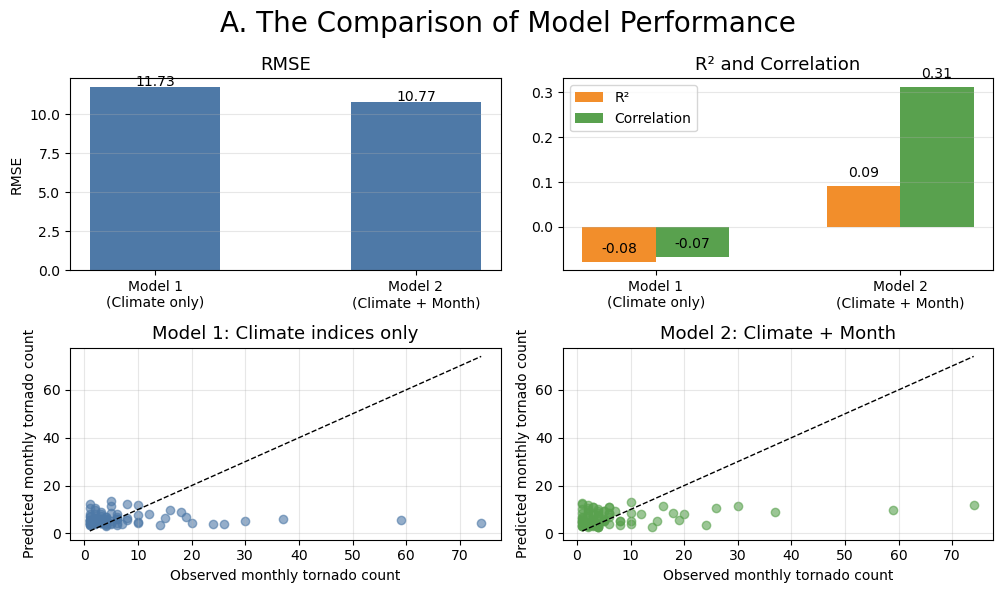

In [31]:
labels = ["Model 1\n(Climate only)", "Model 2\n(Climate + Month)"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
ax_rmse, ax_r2corr, ax_sc1, ax_sc2 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

# RMSE
ax = ax_rmse

ax.bar(labels, [rmse_1, rmse_2], color="#4E79A7", width=0.5)
ax.set_title("RMSE", fontsize=13)
ax.set_ylabel("RMSE")
ax.grid(axis="y", alpha=0.3)

for i, v in enumerate([rmse_1, rmse_2]):
    ax.text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=10)


# R2 and correlation
ax2 = ax_r2corr

x = np.arange(len(labels))
w = 0.3

ax2.bar(x - w/2, [r2_1, r2_2], width=w,
        label="R²", color="#F28E2B")
ax2.bar(x + w/2, [corr_1, corr2], width=w,
        label="Correlation", color="#59A14E")

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title("R² and Correlation", fontsize=13)
ax2.grid(axis="y", alpha=0.3)
ax2.legend()

for i, v in enumerate([r2_1, r2_2]):
    ax2.text(i - w/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)

for i, v in enumerate([corr_1, corr2]):
    ax2.text(i + w/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)


# Scatter plot Model 1
mn = min(y1_test.min(), y1_pred.min(), y2_test.min(), y2_pred.min())
mx = max(y1_test.max(), y1_pred.max(), y2_test.max(), y2_pred.max())

ax_sc1.scatter(y1_test, y1_pred, alpha=0.6, color="#4E79A7")
ax_sc1.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax_sc1.set_title("Model 1: Climate indices only", fontsize=13)
ax_sc1.set_xlabel("Observed monthly tornado count")
ax_sc1.set_ylabel("Predicted monthly tornado count")
ax_sc1.grid(alpha=0.3)


# Scatter plot Model 2
ax_sc2.scatter(y2_test, y2_pred, alpha=0.6, color="#59A14E")
ax_sc2.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax_sc2.set_title("Model 2: Climate + Month", fontsize=13)
ax_sc2.set_xlabel("Observed monthly tornado count")
ax_sc2.set_ylabel("Predicted monthly tornado count")
ax_sc2.grid(alpha=0.3)

plt.suptitle("A. The Comparison of Model Performance", fontsize=20)
plt.tight_layout()
plt.show()

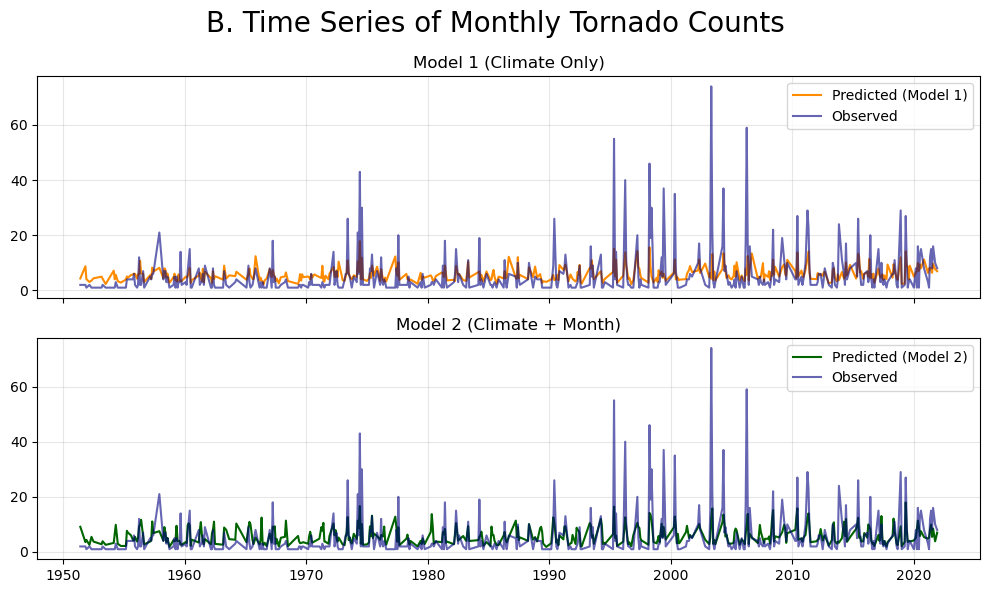

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Model 1
axes[0].plot(df['time'], best_pipe1.predict(X1), 
             label="Predicted (Model 1)", color='darkorange')
axes[0].plot(df['time'], y1, 
             label="Observed", color='navy', alpha=0.6)

axes[0].set_title("Model 1 (Climate Only)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Model 2
axes[1].plot(df['time'], best_pipe2.predict(X2), 
             label="Predicted (Model 2)", color='darkgreen')
axes[1].plot(df['time'], y2,
             label="Observed", color='navy', alpha=0.6)

axes[1].set_title("Model 2 (Climate + Month)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("B. Time Series of Monthly Tornado Counts", fontsize=20)
plt.tight_layout()
plt.show()


### **ANALYSIS ON MODEL PERFORMANCE**

In Figure A panels of RMSE, R2 and corr show that Model 2 outperform Model 1 as it also count for seasonal variation to the prediction of tornado. However, the last panel of figure A show that both models have poor performance, especially in capturing the large amount of tornado. We can confirm their performance by evaluating the time series plot in Figure B. Figure B indicates a good agreement with the scatter plots in Figure A. Both model struggle in capture the high amount of tornado count but tend to overestimate the lower amount of tornado. 

In [37]:
X2_fe_all = best_pipe2[:-1].transform(X2)
X1_fe_all = best_pipe1[:-1].transform(X1)

feat_names1 = np.array(X1_fe_all.columns)
feat_names2 = np.array(X2_fe_all.columns)


rf1 = best_pipe1.named_steps['rf']
rf2 = best_pipe2.named_steps['rf']


In [38]:
importances1 = rf1.feature_importances_
importances2 = rf2.feature_importances_

fi1 = pd.Series(importances1, index=feat_names1).sort_values(ascending=True)
fi2 = pd.Series(importances2, index=feat_names2).sort_values(ascending=True)

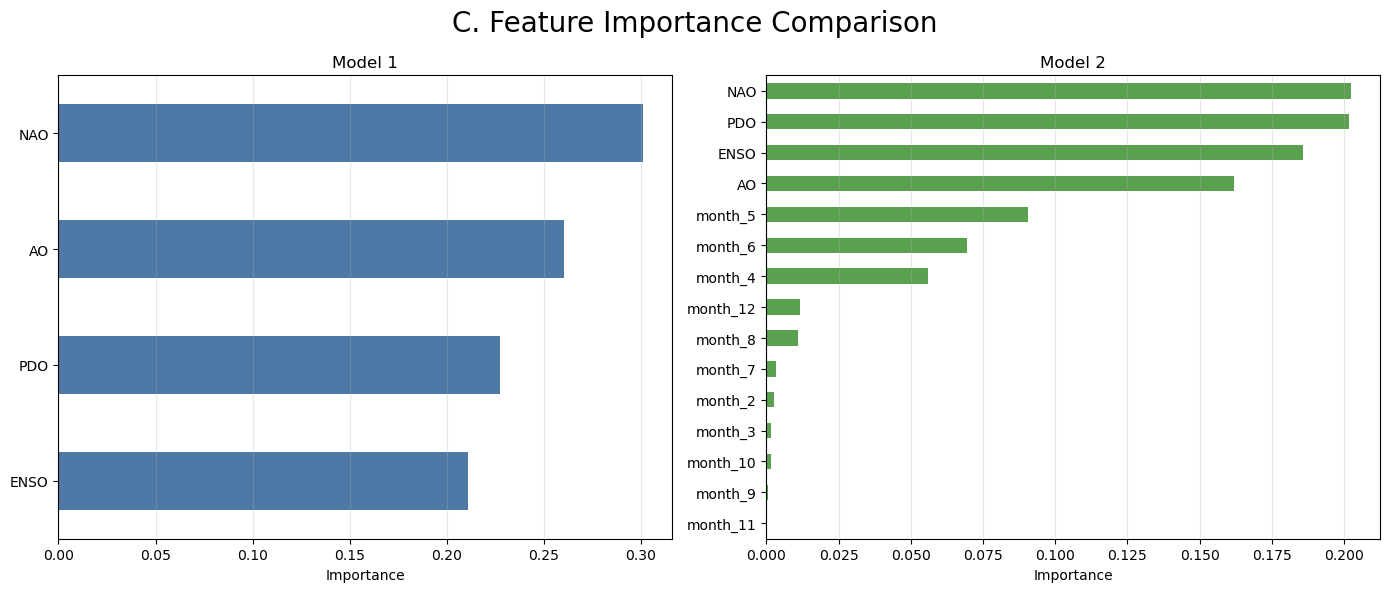

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Model 1
fi1.tail(15).plot(
    kind='barh',
    ax=axes[0],
    color='#4E79A7'
)

axes[0].set_title("Model 1")
axes[0].set_xlabel("Importance")
axes[0].grid(axis='x', alpha=0.3)

# Model 2
fi2.tail(15).plot(
    kind='barh',
    ax=axes[1],
    color='#59A14E'
)

axes[1].set_title("Model 2")
axes[1].set_xlabel("Importance")
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle("C. Feature Importance Comparison", fontsize=20)
plt.tight_layout()
plt.show()


In [ ]:
def multipass_perm(estimator, X, y, n_repeats=20, n_passes=3, random_state=42):
    rn = np.random.RandomState(random_state)
    X_work = X.copy()
    history = []

    for p in range(n_passes):
        r = permutation_importance(
            estimator,
            X_work,
            y,
            n_repeats=n_repeats,
            random_state=rn.randint(0, 10_000),
            n_jobs=4
        )

        history.append({
            "result": r,
            "features": np.array(X_work.columns)
        })

        top_idx = np.argmax(r.importances_mean)
        top_feat = X_work.columns[top_idx]
        print(f"Pass {p+1}: disabling {top_feat}")

        X_work[top_feat] = rn.permutation(X_work[top_feat].values)

    return history


In [43]:
history_mpp_1 = multipass_perm(
    rf1, X1_fe_all, y1,
    n_repeats=20, n_passes=3, random_state=42
)

history_mpp_2 = multipass_perm(
    rf2, X2_fe_all, y2,
    n_repeats=20, n_passes=3, random_state=42
)

Pass 1: disabling NAO
Pass 2: disabling AO
Pass 3: disabling PDO
Pass 1: disabling month_5
Pass 2: disabling month_6
Pass 3: disabling ENSO


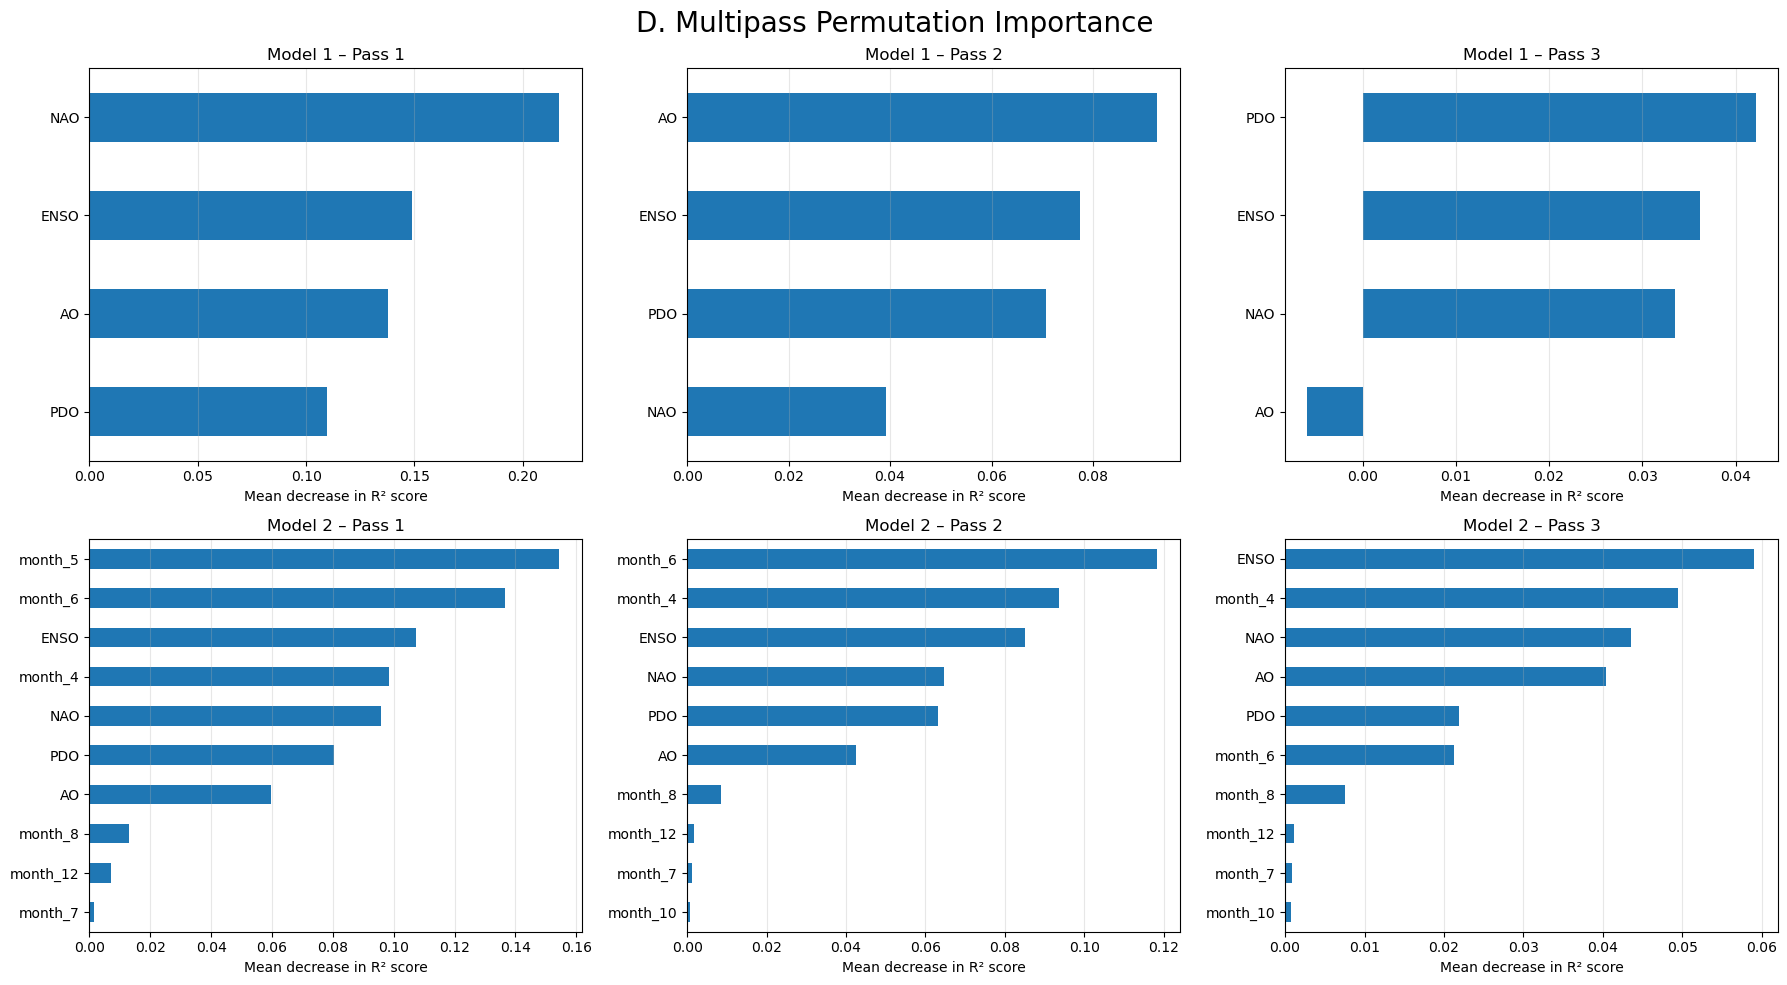

In [55]:
n_passes = 3
topk = 10

fig, axes = plt.subplots(2, n_passes, figsize=(18, 10), sharex=False, sharey=False)

models = {
    "Model 1": history_mpp_1,
    "Model 2": history_mpp_2
}

for row_idx, (model_name, history) in enumerate(models.items()):
    for pass_idx in range(n_passes):

        h = history[pass_idx]
        r_pass = h["result"]
        feats  = h["features"]

        mean_imp = pd.Series(r_pass.importances_mean, index=feats)
        mean_imp = mean_imp.sort_values()
        imp_top = mean_imp.tail(topk)

        ax = axes[row_idx, pass_idx]
        imp_top.plot(kind='barh', ax=ax)

        ax.set_title(f"{model_name} – Pass {pass_idx+1}", fontsize=12)
        ax.set_xlabel("Mean decrease in R² score")
        ax.grid(axis="x", alpha=0.3)

plt.suptitle("D. Multipass Permutation Importance", fontsize=20)
plt.tight_layout()
plt.show()


### **ANALYSIS ON FEATURE IMPORTANCE & MULTIPASS PERMUTATION**

Figure C indicates that Model 1 and Model 2 have different importance of contributor composition to the prediction. Model 1 has NAO as the strongest contributor, while Model 2 still has climate indices as the dominant contributor but month also play important roles in the prediction.

Figure D show the rank if we remove the most dominant predictor. In Model 1, the influnce of each climate index changes as we shuffle other features, indicating overlap between climate indices. Meanwhile, Model 2 still show that seasonal features (month_5 and month_6) are the most dominant predictor. Once we turn off the seasonal features, the climate indices start to play their roles. This finding explain that seasonal features can explain the tornado variability better than climate indices. 

In [67]:
shap.initjs()

X_shap_1 = X1_fe_all
X_shap_2 = X2_fe_all

explainer_1 = shap.TreeExplainer(rf1)
explainer_2 = shap.TreeExplainer(rf2)
shap_values_1 = explainer_1.shap_values(X_shap_1)
shap_values_2 = explainer_2.shap_values(X_shap_2)

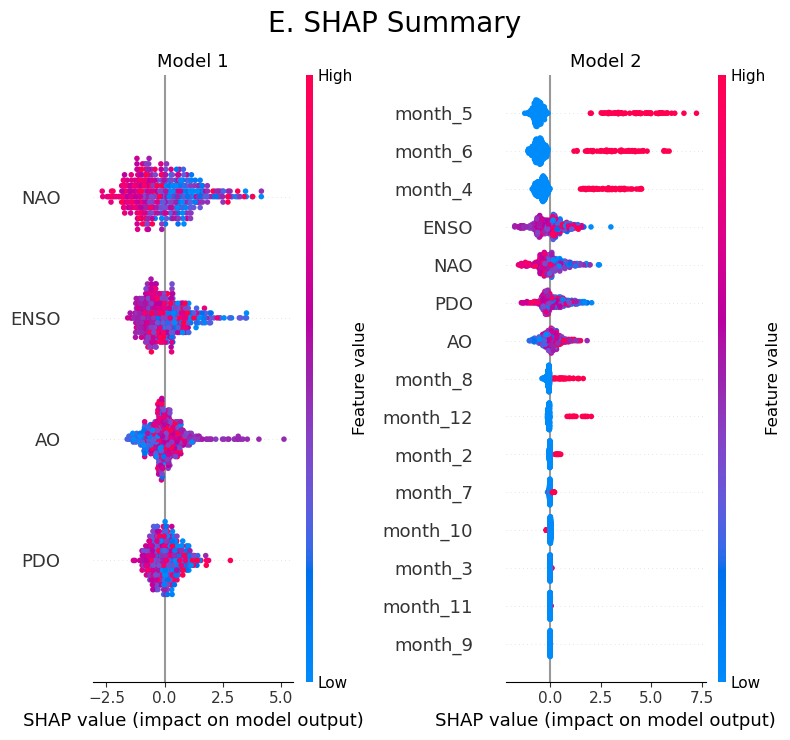

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

# Model 1
plt.sca(axes[0])
shap.summary_plot(
    shap_values_1,
    X_shap_1,
    plot_type="dot",
    show=False,
    max_display=15
)

axes[0].set_title("Model 1", fontsize=13)


# Model 2
plt.sca(axes[1])
shap.summary_plot(
    shap_values_2,
    X_shap_2,
    plot_type="dot",
    show=False,
    max_display=15
)

axes[1].set_title("Model 2", fontsize=13)


plt.suptitle("E. SHAP Summary", fontsize=20)
plt.tight_layout()
plt.show()


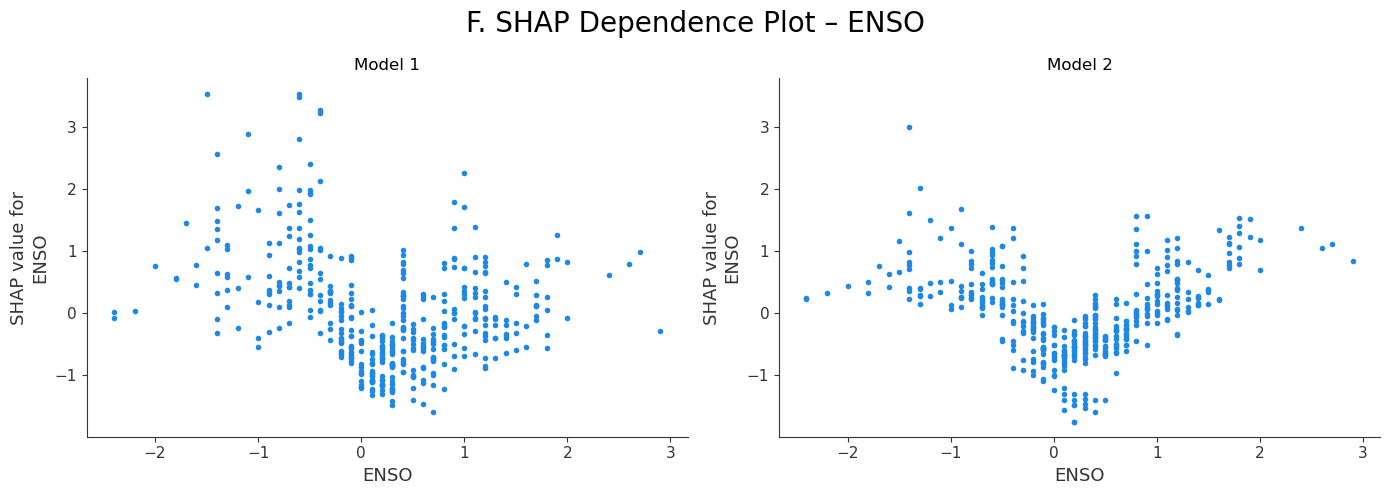

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# model 1
shap.dependence_plot(
    'ENSO',
    shap_values_1,
    X_shap_1,
    interaction_index=None,
    show=False,
    ax=axes[0]
)
axes[0].set_title("Model 1", fontsize=12)

# Model 2
shap.dependence_plot(
    'ENSO',
    shap_values_2,
    X_shap_2,
    interaction_index=None,
    show=False,
    ax=axes[1]
)
axes[1].set_title("Model 2", fontsize=12)

ymins = []
ymaxs = []

for ax in axes:
    ymin, ymax = ax.get_ylim()
    ymins.append(ymin)
    ymaxs.append(ymax)

common_ymin = min(ymins)
common_ymax = max(ymaxs)

for ax in axes:
    ax.set_ylim(common_ymin, common_ymax)

plt.suptitle("F. SHAP Dependence Plot – ENSO", fontsize=20)
plt.tight_layout()
plt.show()


### **ANALYSIS ON SHAP**

Figure E:

Model 1 has quite similar contribution for each predictors and show non linear influence on tornado counts. Model 2 show a distinct impact between predictior where seasonal predictior (month_5, month_6 and month_4) act as dominant predictors that reflect a strong influence on the increasing of tornado counts. 

Figure F show a nonlinear relationship between ENSO and tornado prediction for both models. SHAP analysis for both models have U-shape plots. This explain that for negative ENSO (La Nina) yields to more tornado production compare to neutral or positive ENSO. The difference between Model 1 and Model 2 is plot in Model 2 indicates a change as we involve seasonal factors. Involving seasonal influence decreasing the amplitude. This means that ENSO still has influence to the tornado prediction but its role is weaker as we incorporate seasonal factor to the prediction.